## This exercise is about M2_part2
Be sure to examine and follow the rubric for this assignment. The report should contain an introduction, results, discussion and conclusion. Answers should be more comprehensive than above. Take care to format figures, tables etc. Justify your actions and conclusions. 
### Question 
- Can fecal microbiome sampling replace biochemical biomarkers for identifying different stages of bowel cancer? 
- 45 bowel cancer patients (from stage 1 to 4, with 4 being worst) were tested using 9 blood biomarkers and fecal microbiome sampling containing 23 bacteria (from Order to Species). Metadata includes patient's declared gender. 
- Carry out preprocessing, PLS, modeling and classification on the microbiome and biomarker data, along with any relevant analyses learned in M1 + M2. 

### Consider:
- Which biomarkers and bacteria are associated with the different stages of bowel cancer?
- Can you identify the relevant variables using Effects Plots?
- How well does the microbiome model the biomarkers?
- What can the bacteria identify that biomarkers cannot?
- Do bacteria or biomarkers classify the disease levels better?
- Are there any issues with the design?

## Preprocessing

1. loading the data 

In [1]:
import pandas as pd 

In [2]:
cancer_df = pd.read_csv('M3_CancerMod.csv')
cancer_df

,Sample,Condition,Set,Gender,Age,miRNA10,miRNA12,miRNA15,miRNA24,miRNA36,...,Christensenellaceae,Helicobacteraceae,Bizzozeronii,H_Pylori,Ruminococcaceae,Oscillospira,Ruminococcus,Mogibacteriaceae,Sutterella,Anaeroplasma
0,1,Stage3,A,F,48,32.38,8.643,1.023,48.52,4.017,...,0.000000,0.004372,0.021419,0.008131,0.030453,0.170548,0.014665,0.000000,0.000000,0.000000
1,2,Stage2,A,M,49,37.40,NaN,0.921,51.58,5.290,...,0.000151,0.004317,0.012514,0.002909,0.041298,0.263042,0.013428,0.000151,0.007611,0.000000
2,3,Stage3,A,M,40,52.16,8.682,0.490,72.83,9.282,...,0.000000,0.005343,0.035647,0.005786,0.014161,0.149201,0.013814,0.000154,0.000000,0.000000
3,4,Stage2,A,F,54,25.18,4.307,0.560,34.20,2.920,...,0.000195,0.003955,0.012579,0.002905,0.025016,0.257947,0.024303,0.000207,0.000000,0.000207
4,5,Stage2,A,M,36,34.67,8.439,1.140,49.83,3.666,...,0.000000,0.005404,0.022802,0.002335,0.029067,0.172859,0.008122,0.000300,0.000000,0.001178
5,6,Stage1,A,M,24,39.27,5.255,0.698,52.06,4.934,...,0.000267,0.003412,0.008172,0.004606,0.060392,0.188013,0.019195,0.000520,0.000000,0.003749
6,7,Stage4,A,M,57,37.82,6.475,0.572,52.56,5.941,...,0.000000,0.007837,0.082707,0.015646,0.028597,0.134221,0.016230,0.000000,0.000000,0.000000
7,8,Stage2,A,F,54,37.44,7.766,1.033,52.76,4.502,...,0.000192,0.006303,0.014867,0.003817,0.041748,0.168266,0.013039,0.000160,0.000000,0.008821
8,9,Stage4,A,F,56,41.71,9.825,0.683,70.47,16.126,...,0.000000,0.005387,0.032978,0.019856,0.024137,0.129154,0.008889,0.000000,0.000000,0.000000
9,10,Stage4,A,M,66,51.11,9.863,1.094,75.62,11.245,...,0.000000,0.007309,0.051234,0.010525,0.019563,0.111580,0.010768,0.000000,0.000000,0.000000


Drop rows with any NaN values by index

In [3]:
# drops = cancer_df[cancer_df.isna().any(axis=1)].index.tolist()
# print(drops)
# cancer_df = cancer_df.drop(drops)
# cancer_df

In [4]:
print(cancer_df.columns)
print(cancer_df.shape)


Index(['Sample', 'Condition', 'Set', 'Gender', 'Age', 'miRNA10', 'miRNA12',
       'miRNA15', 'miRNA24', 'miRNA36', 'GDf13', 'GDf9', 'GDf6', 'GDf5',
       'Helicobacter', 'Coriobacteriaceae', 'Bacteroidales', 'Campylobacter',
       'Lactobacillus', 'Blautia', 'S247', 'Odoribacter', 'Mucispirillum',
       'Campylobacterales', 'Bromii', 'Clostridiales', 'Christensenellaceae',
       'Helicobacteraceae', 'Bizzozeronii', 'H_Pylori', 'Ruminococcaceae',
       'Oscillospira', 'Ruminococcus', 'Mogibacteriaceae', 'Sutterella',
       'Anaeroplasma'],
      dtype='object')
(45, 36)


Let's identify data with biomarkers, bacterias and stages.


In [5]:
# 9 biomakers
biomarkers_list = cancer_df.columns[5:14].to_list()
print(len(biomarkers_list))
# fecal microbiome sampling containing 23 bacteria
bacteria_list = cancer_df.columns[14:].to_list()
print(bacteria_list)
print(len(bacteria_list))

# get colors and IDs
levs = cancer_df['Condition'].to_list()
myid = cancer_df['Sample'].to_list()

# set Condition as catgory
cat = 'Condition'



9
['Helicobacter', 'Coriobacteriaceae', 'Bacteroidales', 'Campylobacter', 'Lactobacillus', 'Blautia', 'S247', 'Odoribacter', 'Mucispirillum', 'Campylobacterales', 'Bromii', 'Clostridiales', 'Christensenellaceae', 'Helicobacteraceae', 'Bizzozeronii', 'H_Pylori', 'Ruminococcaceae', 'Oscillospira', 'Ruminococcus', 'Mogibacteriaceae', 'Sutterella', 'Anaeroplasma']
22


Replace outliers with median value by same stage groups

In [6]:
import numpy as np
import pandas as pd

# Function to identify and replace outliers and NaN values with median
def replace_outliers_and_nan_with_median(df, Condition, replaced_columns):
    for column in replaced_columns:
        # Group by the specified condition
        grouped = df.groupby(Condition)

        # Define a function to replace outliers and NaN with median
        def replace_outliers_and_nan(group):
            # Calculate Q1 (25th percentile) and Q3 (75th percentile)
            Q1 = group[column].quantile(0.25)
            Q3 = group[column].quantile(0.75)
            IQR = Q3 - Q1

            # Define the outlier range
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            # Calculate the median for the group
            median = group[column].median()

            # Replace outliers with the median
            group[column] = np.where((group[column] < lower_bound) | (group[column] > upper_bound), median, group[column])

            # Replace NaN values with the median
            group[column].fillna(median, inplace=True)

            return group

        # Apply the replacement function to each group
        df = grouped.apply(replace_outliers_and_nan).reset_index(level=Condition, drop=True)

    return df

# List of columns to process
replaced_columns = [*biomarkers_list, *bacteria_list]  # Modify this list to include all columns

# Replace outliers and NaN values, grouped by the 'Condition' column
cancer_df_outlier_and_nan = replace_outliers_and_nan_with_median(cancer_df, 'Condition', replaced_columns)

# Display the resulting DataFrame and statistics
cancer_df_outlier_and_nan.describe()


cancer_df_outlier_and_nan.to_csv("cancer_mod_median.csv", index=False)


C:\Users\Yao_L\AppData\Local\Temp\ipykernel_26848\1759775035.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  group[column].fillna(median, inplace=True)
C:\Users\Yao_L\AppData\Local\Temp\ipykernel_26848\1759775035.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

Split the data into X and y 

In [63]:
# X explanatory data: which we used to predict
X = cancer_df_outlier_and_nan[bacteria_list]
# y : predictive targets
y = cancer_df_outlier_and_nan[biomarkers_list]
print(f'X data is {X}')
print(f'y data is {y}')

X data is     Helicobacter  Coriobacteriaceae  Bacteroidales  Campylobacter  \
5       0.000000           0.001502       0.027128       0.162136   
11      0.000000           0.000000       0.018854       0.168395   
15      0.000000           0.000864       0.018575       0.155126   
22      0.000000           0.000736       0.013029       0.155126   
23      0.000000           0.000000       0.020781       0.130926   
31      0.000182           0.001289       0.014944       0.089786   
32      0.000000           0.000993       0.010108       0.117329   
33      0.000000           0.000399       0.007986       0.160958   
36      0.000114           0.002790       0.015510       0.126012   
37      0.000000           0.000000       0.017823       0.245739   
40      0.000000           0.000000       0.025930       0.149294   
41      0.000000           0.000864       0.017072       0.047118   
1       0.000972           0.002406       0.008876       0.156171   
3       0.002036        

Explnatory Data Analysis

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

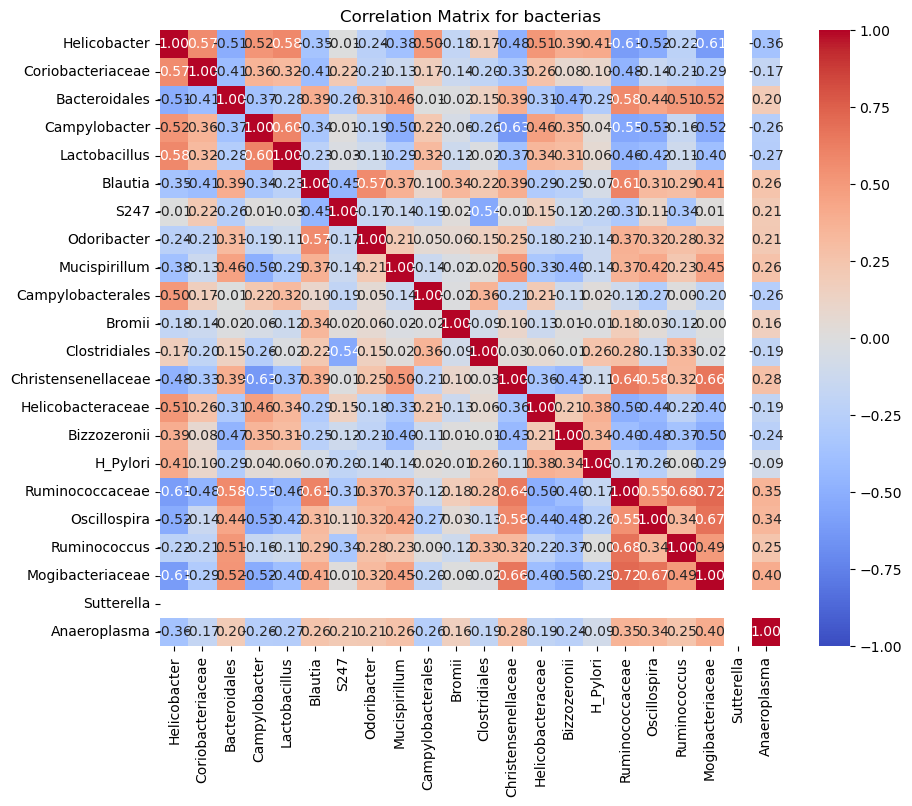

(45, 22)
(45, 22)


In [64]:
# calculate correlation matrix
corr_matrix = X.corr()
# Plotting the correlation matrix of features
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1)
plt.title('Correlation Matrix for bacterias')
plt.show()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column].abs()>0.9)]
X_dropped = X.drop(X[to_drop], axis=1)
print(X.shape)
print(X_dropped.shape)


# delete the features that highly correlated (>0.9)



## PLS 

Let's try to plot figure with 5 comps

In [10]:
X.columns

Index(['Helicobacter', 'Coriobacteriaceae', 'Bacteroidales', 'Campylobacter',
       'Lactobacillus', 'Blautia', 'S247', 'Odoribacter', 'Mucispirillum',
       'Campylobacterales', 'Bromii', 'Clostridiales', 'Christensenellaceae',
       'Helicobacteraceae', 'Bizzozeronii', 'H_Pylori', 'Ruminococcaceae',
       'Oscillospira', 'Ruminococcus', 'Mogibacteriaceae', 'Sutterella',
       'Anaeroplasma'],
      dtype='object')

In [11]:
bacteria_list

['Helicobacter',
 'Coriobacteriaceae',
 'Bacteroidales',
 'Campylobacter',
 'Lactobacillus',
 'Blautia',
 'S247',
 'Odoribacter',
 'Mucispirillum',
 'Campylobacterales',
 'Bromii',
 'Clostridiales',
 'Christensenellaceae',
 'Helicobacteraceae',
 'Bizzozeronii',
 'H_Pylori',
 'Ruminococcaceae',
 'Oscillospira',
 'Ruminococcus',
 'Mogibacteriaceae',
 'Sutterella',
 'Anaeroplasma']

In [12]:
bacteria_list

['Helicobacter',
 'Coriobacteriaceae',
 'Bacteroidales',
 'Campylobacter',
 'Lactobacillus',
 'Blautia',
 'S247',
 'Odoribacter',
 'Mucispirillum',
 'Campylobacterales',
 'Bromii',
 'Clostridiales',
 'Christensenellaceae',
 'Helicobacteraceae',
 'Bizzozeronii',
 'H_Pylori',
 'Ruminococcaceae',
 'Oscillospira',
 'Ruminococcus',
 'Mogibacteriaceae',
 'Sutterella',
 'Anaeroplasma']

In [13]:
X = X.drop(columns=['Sutterella'], axis=1)
# also delete from the list cause i'll use the list for name 
bacteria_list_mod = ['Helicobacter',
 'Coriobacteriaceae',
 'Bacteroidales',
 'Campylobacter',
 'Lactobacillus',
 'Blautia',
 'S247',
 'Odoribacter',
 'Mucispirillum',
 'Campylobacterales',
 'Bromii',
 'Clostridiales',
 'Christensenellaceae',
 'Helicobacteraceae',
 'Bizzozeronii',
 'H_Pylori',
 'Ruminococcaceae',
 'Oscillospira',
 'Ruminococcus',
 'Mogibacteriaceae',
 'Anaeroplasma']


In [14]:

 
from sklearn.cross_decomposition import PLSRegression
from scipy.stats import zscore
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [15]:
len(X.columns)

21

In [16]:
y

,miRNA10,miRNA12,miRNA15,miRNA24,miRNA36,GDf13,GDf9,GDf6,GDf5
5,39.27,5.2550,0.698,52.060,4.9340,0.739,0.9704,0.033,0.0340
11,22.73,3.8560,0.659,31.810,3.1840,0.699,0.6200,0.031,0.0300
15,51.14,5.1570,0.854,49.595,12.2410,1.039,1.0480,0.032,0.0335
22,36.57,5.1570,0.931,49.595,12.8560,1.066,1.3860,0.023,0.0230
23,43.12,4.5200,0.792,58.010,5.0385,0.878,1.2600,0.029,0.0230
31,33.37,4.8230,0.696,45.410,5.0710,0.756,0.6320,0.034,0.0400
32,33.14,6.5630,0.973,46.490,3.6970,1.003,1.0690,0.026,0.0310
33,36.70,5.2650,0.851,49.830,5.0060,0.981,0.9920,0.025,0.0330
36,36.27,4.9770,0.796,48.430,4.5640,0.862,0.9060,0.042,0.0350
37,40.52,5.8830,0.857,55.880,6.3200,0.969,1.2510,0.040,0.0510


In [17]:
# build the model
pls = PLSRegression(n_components=5, scale=True)

# fit X and y
pls.fit(X, y)

PLSRegression(n_components=5)

In [18]:
# Extract loadings and scores
t_pls = pls.x_scores_
w_pls = pls.x_weights_
q_pls = pls.y_loadings_


In [19]:
# set color map
colordic = {'Stage1': 'red', 'Stage2': 'blue','Stage3':'yellow', 'Stage4':'green'}
# Plotting the PLS Bi-plot
plt.figure(figsize=(10,8))

# Extract loadings and scores
t_pls = pls.x_scores_
w_pls = pls.x_weights_
q_pls = pls.y_loadings_

<Figure size 1000x800 with 0 Axes>

In [20]:
len(w_pls)

21

In [21]:
# Scaling factors for biplot
wscale = 5
qscale = 15
sscale = 1

In [22]:
len(bacteria_list)

22

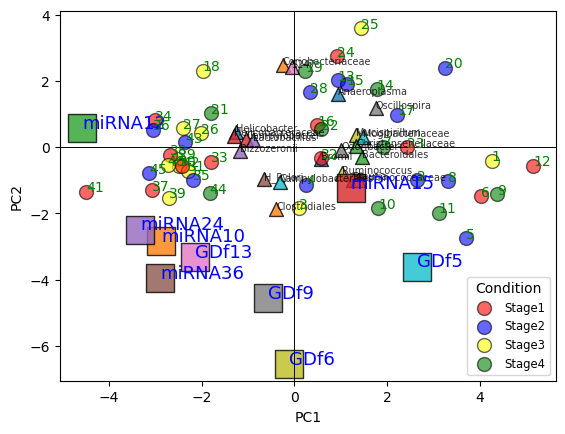

In [23]:
# Plot the w loadings (explanatory variables)
for i in range(len(w_pls)):
    plt.scatter(w_pls[i][0] * wscale, w_pls[i][1] * wscale, s=100, alpha=0.8, marker='^', edgecolor='black')
    plt.text(w_pls[i][0] * wscale, w_pls[i][1] * wscale, bacteria_list_mod[i], fontsize=7, color='black', alpha=0.8)

# Plot the q loadings (response variables)
for i in range(len(q_pls)):
    plt.scatter(q_pls[i][0] * qscale, q_pls[i][1] * qscale, s=400, alpha=0.8, marker='s', edgecolor='black')
    plt.text(q_pls[i][0] * qscale, q_pls[i][1] * qscale, biomarkers_list[i], fontsize=13, color='blue')

# Plot the samples (T)
used = []
scores = t_pls
for i in range(len(scores)):
    plt.text(scores[i][0] * sscale, scores[i][1] * sscale, myid[i], fontsize=10, color='green')
    if levs[i] in used:
        plt.scatter(scores[i][0] * sscale, scores[i][1] * sscale, s=100, alpha=0.6, color=colordic[levs[i]], edgecolor='black')
    else:
        plt.scatter(scores[i][0] * sscale, scores[i][1] * sscale, s=100, label=levs[i], color=colordic[levs[i]], alpha=0.6, edgecolor='black')
        used.append(levs[i])

# Add axis lines
plt.axhline(0, color='k', linestyle='-', linewidth=0.7)
plt.axvline(0, color='k', linestyle='-', linewidth=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')

# Reorder legend handles and labels to your preferred order
handles, labels = plt.gca().get_legend_handles_labels()

# Create a custom order 
order = [2, 1, 0, 3]  # Assuming 'Stage1' is at index 2, 'Stage2' at 1, 'Stage3' at 0, and 'Stage4' at 3

# Apply the new order to the legend
plt.legend([handles[idx] for idx in order], [labels[idx] for idx in order], title=cat, loc=4, fontsize='small')

plt.show()

Check the performance of model by calculating R2, MSE and Q2

## Effect plots

In [24]:
import statsmodels.formula.api as smf

In [25]:
# declear a function to comparison all possible combinations
def test_linear_regression_combinations(X, y):
  # create a dataframe to format the table:
  results_table = pd.DataFrame(index=X.columns, columns=y.columns)

  # loop over each column in y and X
  for y_col in y.columns:
    for x_col in X.columns:
      df_combined = pd.DataFrame({y_col:y[y_col], x_col: X[x_col]})

      formula = f'{y_col} ~ {x_col}'

      #fit linear regression model
      lin_reg = smf.ols(formula, data=df_combined).fit()

      # Extract the coefficient for variables
      coef = lin_reg.params[x_col]
      p_value = lin_reg.pvalues[x_col]

      # only fill the table if the p_value is <= 0.05
      if p_value <= 0.05:
        results_table.at[x_col, y_col] = coef
      else:
        results_table.at[x_col, y_col] = np.nan
  return results_table 

results_table = test_linear_regression_combinations(X, y)
results_table


,miRNA10,miRNA12,miRNA15,miRNA24,miRNA36,GDf13,GDf9,GDf6,GDf5
Helicobacter,762.952138,235.039417,NaN,1336.892565,290.782506,NaN,NaN,NaN,-0.887838
Coriobacteriaceae,NaN,259.435674,NaN,NaN,NaN,NaN,NaN,-1.149286,-1.760956
Bacteroidales,-800.045244,-207.545435,9.566611,-1391.768081,-283.65785,NaN,NaN,NaN,0.682149
Campylobacter,NaN,18.318633,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lactobacillus,NaN,322.396419,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Blautia,-268.445756,-62.622896,NaN,-405.569135,NaN,NaN,NaN,NaN,0.284101
S247,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.11419,-0.103346
Odoribacter,NaN,-163.083768,NaN,-1040.624443,NaN,NaN,NaN,NaN,NaN
Mucispirillum,-221.553787,-60.164112,NaN,-358.694072,-73.578525,-2.134101,NaN,NaN,0.249444
Campylobacterales,NaN,NaN,NaN,NaN,NaN,18.206297,NaN,NaN,NaN


convert numbers in the dataframe to 1 -1 or 0 base on sign


In [26]:
# fill nan with 0
def fill_na_with_zero(results_table):
    return results_table.fillna(0)

# fill with sign
def convert_sign_to_indicator(results_table):
  results_table = fill_na_with_zero(results_table)

  # define a lambda function to check the sign
  sign_converter = lambda x: 1 if x > 0 else (-1 if x < 0 else 0)

  # Apply this sign_converter function to the entire dataframe using applymap
  converted_table = results_table.map(sign_converter)

  return converted_table

converted_table = convert_sign_to_indicator(results_table)

converted_table





C:\Users\Yao_L\AppData\Local\Temp\ipykernel_26848\3119538916.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return results_table.fillna(0)


,miRNA10,miRNA12,miRNA15,miRNA24,miRNA36,GDf13,GDf9,GDf6,GDf5
Helicobacter,1,1,0,1,1,0,0,0,-1
Coriobacteriaceae,0,1,0,0,0,0,0,-1,-1
Bacteroidales,-1,-1,1,-1,-1,0,0,0,1
Campylobacter,0,1,0,0,0,0,0,0,0
Lactobacillus,0,1,0,0,0,0,0,0,0
Blautia,-1,-1,0,-1,0,0,0,0,1
S247,0,0,0,0,0,0,0,-1,-1
Odoribacter,0,-1,0,-1,0,0,0,0,0
Mucispirillum,-1,-1,0,-1,-1,-1,0,0,1
Campylobacterales,0,0,0,0,0,1,0,0,0


## Model Validation

In [27]:
# # scale X and y
# scaler_X = StandardScaler()
# scaler_y = StandardScaler()

# X_scaled = scaler_X.fit_transform(X)
# X_scaled = scaler_X.fit_transform(X)

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [29]:
# build the model
n_comp = 10
pls = PLSRegression(n_components=n_comp,scale=True)
pls.fit(X_train, y_train)

PLSRegression(n_components=10)

In [30]:
# Transform training and testing sets
X_train_pls = pls.transform(X_train)
X_test_pls = pls.transform(X_test)

d:\Software\Anaconda\envs\WinConda\Lib\site-packages\numpy\core\fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
d:\Software\Anaconda\envs\WinConda\Lib\site-packages\numpy\core\fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
d:\Software\Anaconda\envs\WinConda\Lib\site-packages\numpy\core\fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduct

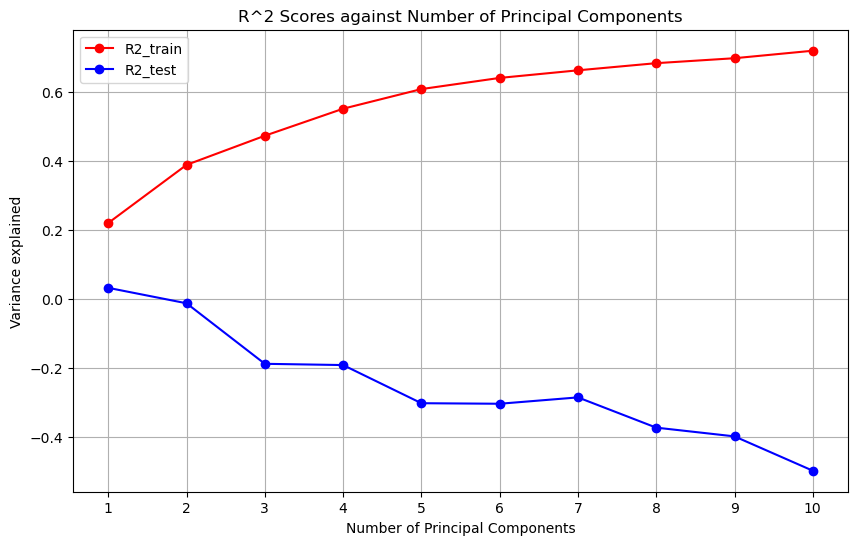

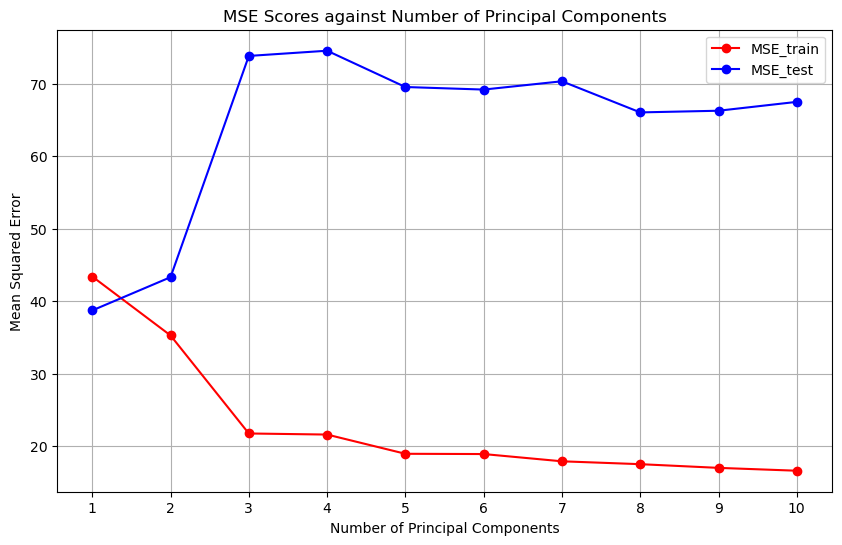

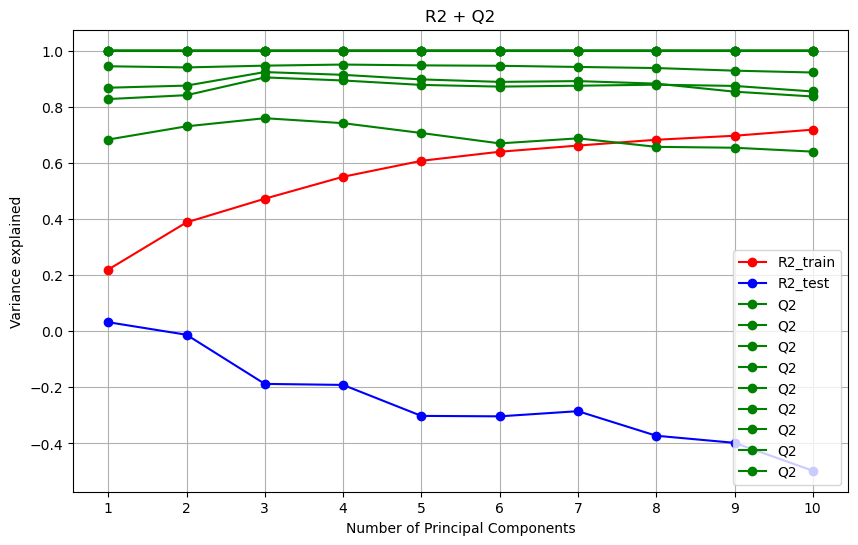

In [31]:
# Lists to store R2 scores and MSE scores and Q2
R2_train_scores = []
R2_test_scores = []
MSE_train_scores = []
MSE_test_scores = []
Q2_scores = []

# Train and calculate R2 for each principal component
for i in range(1, n_comp + 1):
    model = PLSRegression(n_components=i)
    model.fit(X_train_pls[:, :i], y_train)  # Train on the first i components
    
    # Predictions
    y_train_pred = model.predict(X_train_pls[:, :i])
    y_test_pred = model.predict(X_test_pls[:, :i])

    # Calculate R2 and MSE for train and test sets
    R2_train_scores.append(r2_score(y_train, y_train_pred))
    R2_test_scores.append(r2_score(y_test, y_test_pred))
    MSE_train_scores.append(mean_squared_error(y_train, y_train_pred))
    MSE_test_scores.append(mean_squared_error(y_test, y_test_pred))

    # Cross-validation for Q2
    y_cv_pred = cross_val_predict(model, X_train_pls[:, :i], y_train, cv=5)
    ss_res = np.sum((y_train - y_cv_pred) ** 2)  # Residual sum of squares
    ss_total = np.sum((y_train - np.mean(y_train)) ** 2)  # Total sum of squares
    q2 = 1 - (ss_res / ss_total)  # Q2 calculation
    Q2_scores.append(q2)

# Plotting R2 train and test
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(R2_train_scores) + 1), R2_train_scores, marker='o', label='R2_train', color='red')
plt.plot(range(1, len(R2_test_scores) + 1), R2_test_scores, marker='o', label='R2_test', color='blue')
plt.title('R^2 Scores against Number of Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Variance explained')
plt.xticks(range(1, len(R2_train_scores) + 1))
plt.grid()
plt.legend()
plt.show()

# Plotting MSE train and test
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(MSE_train_scores) + 1), MSE_train_scores, marker='o', label='MSE_train', color='red')
plt.plot(range(1, len(MSE_test_scores) + 1), MSE_test_scores, marker='o', label='MSE_test', color='blue')
plt.title('MSE Scores against Number of Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Mean Squared Error')
plt.xticks(range(1, len(MSE_train_scores) + 1))
plt.grid()
plt.legend()
plt.show()

# Plotting R2 and Q2
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(R2_train_scores) + 1), R2_train_scores, marker='o', label='R2_train', color='red')
plt.plot(range(1, len(R2_test_scores) + 1), R2_test_scores, marker='o', label='R2_test', color='blue')
plt.plot(range(1, len(Q2_scores) + 1), Q2_scores, marker='o', label='Q2', color='green')
plt.title('R2 + Q2')
plt.xlabel('Number of Principal Components')
plt.ylabel('Variance explained')
plt.xticks(range(1, len(R2_train_scores) + 1))
plt.grid()
plt.legend()
plt.show()


In [32]:
best_model = PLSRegression(n_components=2)
best_model.fit(X, y)
y_predict = best_model.predict(X)
print(r2_score(y, y_predict))
print(mean_squared_error(y, y_predict))


0.32957325927123765
36.615663636713904


In [33]:
print(y.shape)
type(y_predict)

(45, 9)


numpy.ndarray

Plot observed vs predicted to see how well our model predicts

In [34]:
y_flat = y.to_numpy().flatten()
y_predict_flat = y_predict.flatten()

In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

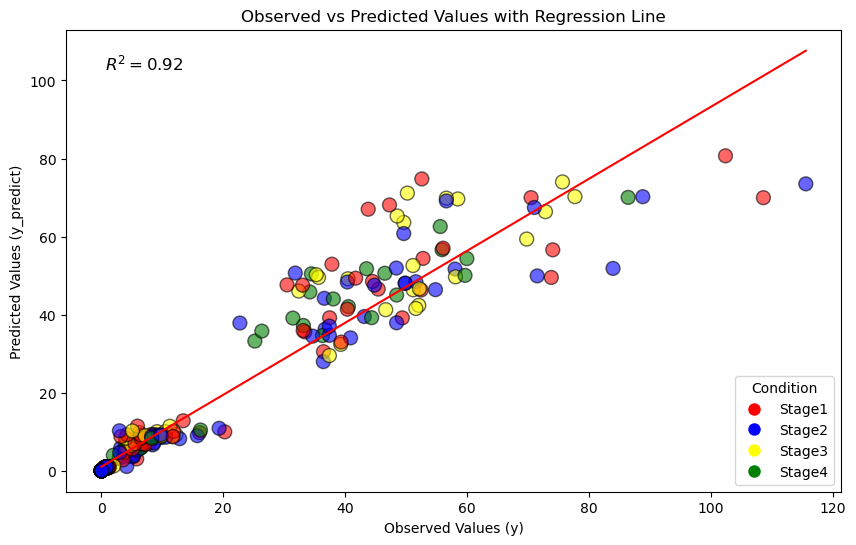

In [36]:

# Fit the PLSRegression model
best_model = PLSRegression(n_components=2)
best_model.fit(X, y)
y_predict = best_model.predict(X)

# Flatten the arrays for plotting
y_flat = y.to_numpy().flatten()
y_predict_flat = y_predict.flatten()

# R2 scores 
r2 = r2_score(y_flat, y_predict_flat)

# Colors for the scatter plot
colors = [colordic[condition] for condition in levs for _ in range(9)]

# Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(y_flat, y_predict_flat, c=colors, alpha=0.6, edgecolors='k', s=100)

# Fit a linear regression model for the regression line
reg_model = LinearRegression()
reg_model.fit(y_flat.reshape(-1, 1), y_predict_flat)  # Reshape for sklearn

# Generate predicted values for the regression line
y_regression_line = reg_model.predict(np.array([np.min(y_flat), np.max(y_flat)]).reshape(-1, 1))

# Plot the regression line
plt.plot([np.min(y_flat), np.max(y_flat)], y_regression_line, color='red', linestyle='-', label='Regression Line')

# Add labels, title, and legend
plt.xlabel('Observed Values (y)')
plt.ylabel('Predicted Values (y_predict)')
plt.title('Observed vs Predicted Values with Regression Line')

# Annotate the R² value on the plot
plt.annotate(f'$R^2 = {r2:.2f}$', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=12, 
             horizontalalignment='left', verticalalignment='top')

# Create custom legend
legend_handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colordic[stage], markersize=10)
                  for stage in colordic.keys()]
plt.legend(legend_handles, colordic.keys(), title="Condition")

# Show the plot
plt.show()


## Classification

In [37]:
from sklearn.preprocessing import LabelEncoder


In [38]:
le = LabelEncoder()


In [39]:
# encode the Conditions to number
cancer_df_outlier_and_nan['Condition'] = le.fit_transform(cancer_df_outlier_and_nan['Condition']) # 
print(f'condition is {cancer_df_outlier_and_nan['Condition']}')

condition is 5     0
11    0
15    0
22    0
23    0
31    0
32    0
33    0
36    0
37    0
40    0
41    0
1     1
3     1
4     1
7     1
12    1
14    1
16    1
19    1
27    1
34    1
35    1
42    1
44    1
0     2
2     2
17    2
24    2
25    2
26    2
28    2
29    2
30    2
38    2
39    2
6     3
8     3
9     3
10    3
13    3
18    3
20    3
21    3
43    3
Name: Condition, dtype: int32


In [40]:
# assign classtor and predctive features
y_class = cancer_df_outlier_and_nan['Condition']

# bacterias
X_bac = cancer_df_outlier_and_nan[bacteria_list_mod]

# biomakers
X_bio = cancer_df_outlier_and_nan[biomarkers_list]

print(X_bac)
print(X_bio)

    Helicobacter  Coriobacteriaceae  Bacteroidales  Campylobacter  \
5       0.000000           0.001502       0.027128       0.162136   
11      0.000000           0.000000       0.018854       0.168395   
15      0.000000           0.000864       0.018575       0.155126   
22      0.000000           0.000736       0.013029       0.155126   
23      0.000000           0.000000       0.020781       0.130926   
31      0.000182           0.001289       0.014944       0.089786   
32      0.000000           0.000993       0.010108       0.117329   
33      0.000000           0.000399       0.007986       0.160958   
36      0.000114           0.002790       0.015510       0.126012   
37      0.000000           0.000000       0.017823       0.245739   
40      0.000000           0.000000       0.025930       0.149294   
41      0.000000           0.000864       0.017072       0.047118   
1       0.000972           0.002406       0.008876       0.156171   
3       0.002036           0.00355

In [ ]:


# X_bac = scaler_bac.fit_transform(X_bac)
# X_bac = scaler_bac.transform(X_bac)

# X_bio = scaler_bio.fit_transform(X_bio)
# X_bio = scaler_bio.transform(X_bio)

In [42]:
# Split for bacteria features
X_train_bac, X_test_bac, y_train_bac, y_test_bac = train_test_split(X_bac, y_class, test_size=0.3)

# split for bio features
X_train_bio, X_test_bio, y_train_bio, y_test_bio = train_test_split(X_bio, y_class, test_size=0.3)

In [43]:
# Scale features
from sklearn.preprocessing import StandardScaler

scaler_bac = StandardScaler()
scaler_bio = StandardScaler()

X_train_bac = scaler_bac.fit_transform(X_train_bac)
X_test_bac = scaler_bac.transform(X_test_bac)

X_train_bio = scaler_bio.fit_transform(X_train_bio)
X_test_bio = scaler_bio.transform(X_test_bio)

In [44]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score


In [45]:
# build knn classifier 
knn_bac = KNeighborsClassifier()

# fit knn classifier for training data 
knn_bac.fit(X_train_bac, y_train_bac)

# predictions
y_pred_train_bac = knn_bac.predict(X_train_bac)

In [46]:
class_names = ['Stage1', 'Stage2', 'Stage3', 'Stage4']

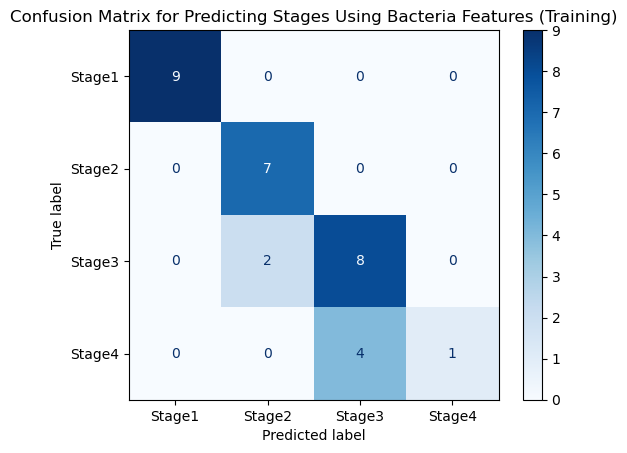

In [47]:
# generate and display the confusion matrix
cm_bac_train = confusion_matrix(y_train_bac, y_pred_train_bac)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_bac_train, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Predicting Stages Using Bacteria Features (Training)')
plt.show()


In [48]:
# accuray 
train_bac_score = accuracy_score(y_train_bac, y_pred_train_bac)
round(train_bac_score,2)

0.81

In [49]:
# precision
train_bac_prec_score = precision_score(y_train_bac, y_pred_train_bac,average='macro')
round(train_bac_prec_score,2)

0.86

let's check the performance by using testing data

In [50]:
# fit knn classifier for training data 
knn_bac.fit(X_test_bac, y_test_bac)

# predictions
y_pred_test_bac = knn_bac.predict(X_test_bac)

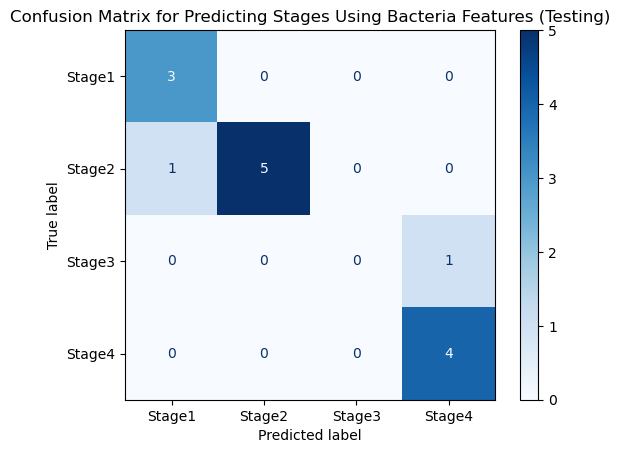

In [51]:
# generate and display the confusion matrix
cm_bac_test = confusion_matrix(y_test_bac, y_pred_test_bac)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_bac_test, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Predicting Stages Using Bacteria Features (Testing)')
plt.show()

In [52]:
# accuray 
test_bac_acc_score = accuracy_score(y_test_bac, y_pred_test_bac)
round(test_bac_acc_score,2)

0.86

In [53]:
# precision
test_bac_prec_score = precision_score(y_test_bac, y_pred_test_bac,average='macro')
round(test_bac_prec_score,2)

d:\Software\Anaconda\envs\WinConda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


0.64

In [62]:
print(classification_report(y_test_bac, y_pred_test_bac))

              precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       1.00      0.83      0.91         6
           2       0.00      0.00      0.00         1
           3       0.80      1.00      0.89         4

    accuracy                           0.86        14
   macro avg       0.64      0.71      0.66        14
weighted avg       0.82      0.86      0.83        14



d:\Software\Anaconda\envs\WinConda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Software\Anaconda\envs\WinConda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Software\Anaconda\envs\WinConda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Let's look at the biomarkers feature

In [54]:
# build knn classifier 
knn_bio = KNeighborsClassifier()

# fit knn classifier for training data 
knn_bio.fit(X_train_bio, y_train_bio)

# predictions
y_pred_train_bio = knn_bio.predict(X_train_bio)

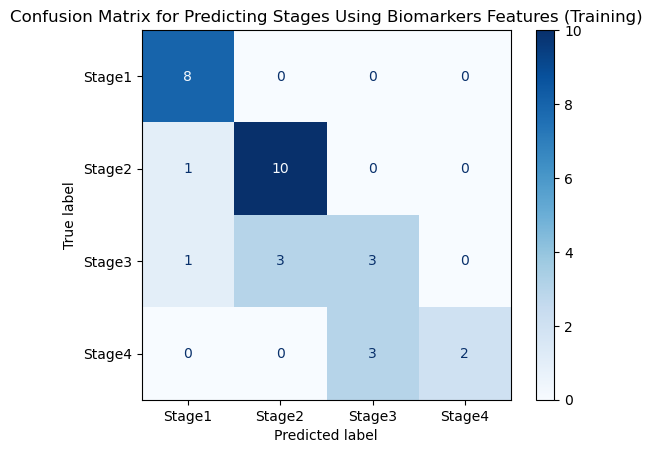

In [55]:
# generate and display the confusion matrix
cm_bio_train = confusion_matrix(y_train_bio, y_pred_train_bio)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_bio_train, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Predicting Stages Using Biomarkers Features (Training)')
plt.show()

In [56]:
# accuray 
train_bio_acc_score = accuracy_score(y_train_bio, y_pred_train_bio)
round(train_bio_acc_score,2)

0.74

In [57]:
# precision
train_bio_prec_score = precision_score(y_train_bio, y_pred_train_bio,average='macro')
round(train_bio_prec_score,2)

0.77

In [58]:


# fit knn classifier for training data 
knn_bio.fit(X_test_bio, y_test_bio)

# predictions
y_pred_test_bio = knn_bio.predict(X_test_bio)

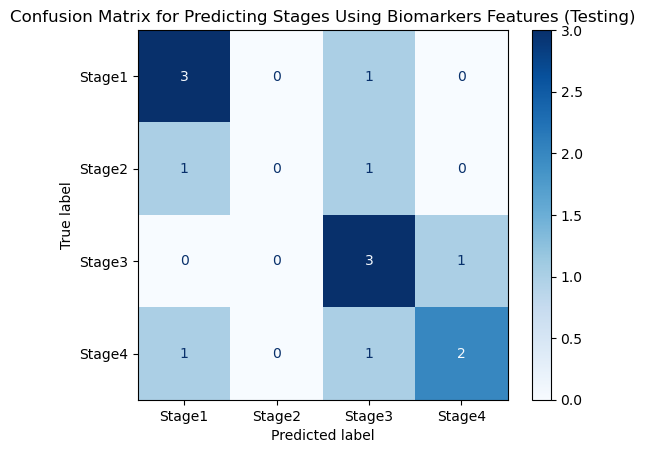

In [59]:
# generate and display the confusion matrix
cm_bio_test = confusion_matrix(y_test_bio, y_pred_test_bio)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_bio_test, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Predicting Stages Using Biomarkers Features (Testing)')
plt.show()

In [60]:
# accuray 
test_bio_acc_score = accuracy_score(y_test_bio, y_pred_test_bio)
round(test_bio_acc_score,2)

0.57

In [61]:
# precision
test_bio_prec_score = precision_score(y_test_bio, y_pred_test_bio,average='macro')
round(test_bio_prec_score,2)

d:\Software\Anaconda\envs\WinConda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


0.44